# K-Moda MMM · Notebook 3: Data Preparation

**Decisiones cerradas en este notebook:**

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| **Agrupación** | 2 bloques (digital + tradicional) | 4 grupos tenían ρ ∈ [0.86, 0.96] → ElasticNet anulaba 2 de 4. Con 2 bloques (ρ ≈ 0.90) hay margen para discriminar |
| **Adstock** | Priors fijos (no calibrar) | Calibración convergía al borde α=0.95 en todos los canales por colinealidad |
| **Saturación** | `log1p(x / k)` con k = percentil 60 | Normaliza escala entre bloques antes de saturar |
| **Target** | `Yt_indexed` (detrended por año) | Los escalones anuales son estructurales, no marketing. Eliminados en ETL |
| **Trend/Year FE** | Ninguno | Ya eliminados por el detrending. Sin trend no hay competencia por varianza |

**Pipeline:** ETL → **Data Preparation** → Modeling → Optimization

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

# ─── Constantes ──────────────────────────────────────────────────────────────
VERSION    = 1
DATE_COL   = "semana_inicio"
TARGET_COL = "venta_neta_total_eur"
TARGET_IDX = "Yt_indexed"

INV_COLS = [
    "inv_paid_search", "inv_social_paid", "inv_video_online", "inv_display",
    "inv_email_crm",   "inv_radio_local", "inv_exterior",     "inv_prensa",
]
FOURIER_COLS = ["fourier_sin1", "fourier_cos1", "fourier_sin2", "fourier_cos2"]
CONTROLES_CALENDARIO = [
    "payday_flag", "rebajas_flag", "black_friday_flag", "navidad_flag",
    "semana_santa_flag", "vacaciones_escolares_flag",
    "incidencia_ecommerce_flag", "festivo_local_intensidad",
]
CONTROLES_CONTINUOS = ["temperatura_media_c", "lluvia_indice", "turismo_indice"]

WAREHOUSE = os.path.join("data", "warehouse", f"version{VERSION}")
os.makedirs(WAREHOUSE, exist_ok=True)

# ── K-Moda brand palette ─────────────────────────────────────────────────────
KM_GOLD      = "#C8A96E"
KM_GOLD_DARK = "#8B6914"
KM_CHARCOAL  = "#2D2D2D"
KM_CREAM     = "#F7F4EF"
KM_GRAY      = "#9E9893"
KM_IVORY     = "#EDE8DC"
KM_CHANNELS  = ["#C8A96E", "#8B6914", "#2D2D2D", "#9E9893"]

plt.rcParams.update({
    "figure.facecolor":  KM_CREAM,
    "axes.facecolor":    KM_CREAM,
    "axes.edgecolor":    KM_GRAY,
    "axes.labelcolor":   KM_CHARCOAL,
    "axes.titlecolor":   KM_CHARCOAL,
    "axes.titlesize":    12,
    "axes.titlepad":     12,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        KM_GRAY,
    "grid.alpha":        0.18,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.5,
    "xtick.color":       KM_GRAY,
    "ytick.color":       KM_GRAY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.7,
    "legend.edgecolor":  KM_GRAY,
    "figure.figsize":    (14, 4.5),
    "figure.dpi":        130,
    "savefig.facecolor": KM_CREAM,
    "savefig.bbox":      "tight",
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Cargar ETL

In [2]:
df = (
    pd.read_csv(os.path.join(WAREHOUSE, "etl.csv"), parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)
print(f"{df.shape} | {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"Yt_indexed: mean={df[TARGET_IDX].mean():.4f}  std={df[TARGET_IDX].std():.4f}")

(258, 50) | 2020-01-06 → 2024-12-09
Yt_indexed: mean=1.0000  std=0.0152


## 2. Agrupación de canales: 8 → 2 bloques

Los 8 canales (y los 4 grupos previos) tienen correlaciones Spearman ρ ∈ [0.83, 0.96]. 
Con `positive=True`, ElasticNet anulaba 2 de 4 grupos porque no puede discriminar entre 
series casi idénticas sin permitir cancelación de signos.

**Diagnóstico del experimento de calibración:**
- 4 grupos: digital_perf ↔ offline ρ=0.96, digital_perf ↔ awareness ρ=0.94
- Resultado: awareness y CRM siempre a β=0

**Solución:** 2 bloques con ρ ≈ 0.90 — suficiente separación para que ElasticNet asigne β > 0 a ambos.

In [3]:
# ═══════════════════════════════════════════════════════════════════
# AGRUPACIÓN: 8 canales → 2 bloques
# ═══════════════════════════════════════════════════════════════════
CHANNEL_GROUPS = {
    "performance": [
        "inv_paid_search",
        "inv_social_paid",
    ],
    "branding_digital": [
        "inv_display",
        "inv_video_online",
    ],
    "offline_medios": [
        "inv_radio_local",
        "inv_prensa",
    ],
    "propios_y_exterior": [
        "inv_email_crm",
        "inv_exterior",
    ],
}

for group_name, cols in CHANNEL_GROUPS.items():
    df[f"inv_{group_name}"] = df[cols].sum(axis=1)

INV_GROUP_COLS = [f"inv_{g}" for g in CHANNEL_GROUPS]

# Verificar correlación entre los 2 bloques
r = df[INV_GROUP_COLS[0]].corr(df[INV_GROUP_COLS[1]])
print(f"Correlación entre los 2 bloques: ρ = {r:.3f}")
print(f"  (antes con 4 grupos: ρ max = 0.96, ahora {r:.3f})")
print()
for g, cols in CHANNEL_GROUPS.items():
    total = df[f"inv_{g}"].sum()
    print(f"  inv_{g:<14s} = {' + '.join(c.replace('inv_','') for c in cols)}")
    print(f"    Total: €{total:,.0f}")

Correlación entre los 2 bloques: ρ = 0.945
  (antes con 4 grupos: ρ max = 0.96, ahora 0.945)

  inv_performance    = paid_search + social_paid
    Total: €23,481,872
  inv_branding_digital = display + video_online
    Total: €13,642,554
  inv_offline_medios = radio_local + prensa
    Total: €11,842,707
  inv_propios_y_exterior = email_crm + exterior
    Total: €10,000,954


## 3. Adstock con priors fijos

La calibración automática no identifica parámetros por canal/grupo: con ρ > 0.86 entre grupos, 
todos convergen a α ≈ 0.90, lag=4 (esquina del grid). Usamos priors de literatura diferenciados 
por mecanismo de respuesta.

In [4]:
def adstock(series, alpha: float, lag: int = 0) -> np.ndarray:
    """Adstock recursivo: A_t = x_{t-lag} + alpha · A_{t-1}."""
    x = pd.Series(series).shift(lag).fillna(0).to_numpy(dtype=float)
    out = np.zeros_like(x)
    for t in range(len(x)):
        out[t] = x[t] + (alpha * out[t-1] if t > 0 else 0.0)
    return out

best_params = {
    "inv_performance": {        # search, social paid
        "alpha": 0.20,      # efecto muy corto (respuesta inmediata)
        "lag": 0
    },
    "inv_branding_digital": {   # display, video online
        "alpha": 0.50,      # memoria media
        "lag": 1
    },
    "inv_offline_medios": {     # radio, prensa
        "alpha": 0.60,      # mayor persistencia
        "lag": 1
    },
    "inv_propios_y_exterior": { # CRM, exterior
        "alpha": 0.70,      # efecto muy persistente (especialmente CRM)
        "lag": 0
    },
}

for col, p in best_params.items():
    print(f"  {col:<20s}  α={p['alpha']}  lag={p['lag']}")

  inv_performance       α=0.2  lag=0
  inv_branding_digital  α=0.5  lag=1
  inv_offline_medios    α=0.6  lag=1
  inv_propios_y_exterior  α=0.7  lag=0


## 4. Adstock + saturación `log1p(x/k)`

Se aplica adstock → saturación con k = percentil 60 de valores positivos. 
La normalización por k pone ambos bloques en la misma escala antes de log1p.

In [5]:
LOGADSTOCK_COLS = []
saturation_k = {}

for col, p in best_params.items():
    ads = adstock(df[col].values, p["alpha"], p["lag"])

    # k = percentil 60 para saturación normalizada
    pos_vals = ads[ads > 0]
    k = float(np.percentile(pos_vals, 60)) if len(pos_vals) > 0 else 1.0
    saturation_k[col] = k

    logcol = f"logadstock_{col.replace('inv_', '')}"
    df[logcol] = np.log1p(ads / k)
    LOGADSTOCK_COLS.append(logcol)

print(f"Logadstock: {LOGADSTOCK_COLS}")
for col, k in saturation_k.items():
    print(f"  {col}: k = {k:,.0f} (p60 del adstock)")

Logadstock: ['logadstock_performance', 'logadstock_branding_digital', 'logadstock_offline_medios', 'logadstock_propios_y_exterior']
  inv_performance: k = 119,733 (p60 del adstock)
  inv_branding_digital: k = 112,584 (p60 del adstock)
  inv_offline_medios: k = 121,273 (p60 del adstock)
  inv_propios_y_exterior: k = 138,806 (p60 del adstock)


### Gráfica 1 · Inversión raw vs logadstock por bloque

Antes y después de aplicar **adstock** (α diferenciado por mecanismo de respuesta) + **saturación log1p(x/k)**.
La transformación suaviza los picos y comprime la escala para que ElasticNet no sobre-pondere semanas de gasto puntualmente alto.

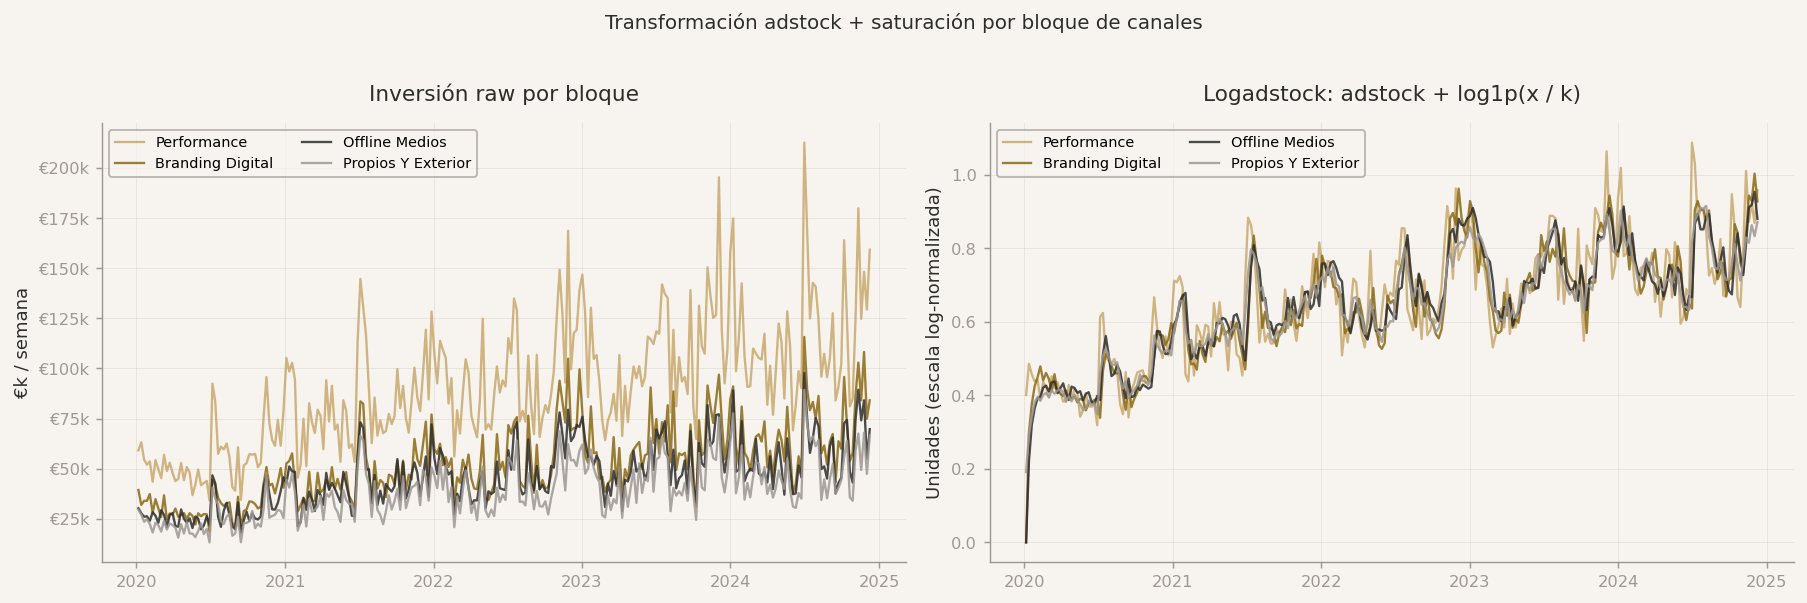

In [6]:
# ── Gráfica 1: inversión raw vs logadstock (lado a lado) ─────────────────────
fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(14, 4.5))

block_labels = [c.replace("inv_", "").replace("_", " ").title() for c in INV_GROUP_COLS]
log_labels   = [c.replace("logadstock_", "").replace("_", " ").title() for c in LOGADSTOCK_COLS]

for col, color, label in zip(INV_GROUP_COLS, KM_CHANNELS, block_labels):
    ax_raw.plot(df[DATE_COL], df[col], lw=1.3, color=color, label=label, alpha=0.85)
ax_raw.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e3:.0f}k"))
ax_raw.xaxis.set_major_locator(mdates.YearLocator())
ax_raw.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_raw.set_title("Inversión raw por bloque")
ax_raw.set_ylabel("€k / semana")
ax_raw.legend(fontsize=8, ncol=2)

for col, color, label in zip(LOGADSTOCK_COLS, KM_CHANNELS, log_labels):
    ax_log.plot(df[DATE_COL], df[col], lw=1.3, color=color, label=label, alpha=0.85)
ax_log.xaxis.set_major_locator(mdates.YearLocator())
ax_log.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_log.set_title("Logadstock: adstock + log1p(x / k)")
ax_log.set_ylabel("Unidades (escala log-normalizada)")
ax_log.legend(fontsize=8, ncol=2)

fig.suptitle("Transformación adstock + saturación por bloque de canales",
             fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "dp_g1_raw_vs_logadstock.png"), dpi=150)
plt.show()

### Gráfica 2 · Señal logadstock vs ventas (Yt_indexed)

Scatter de cada bloque transformado contra el target indexado.
Un **r > 0** confirma que la señal de cada canal co-varía con las ventas —
requisito mínimo para que el coeficiente β sea positivo y significativo en el modelo.

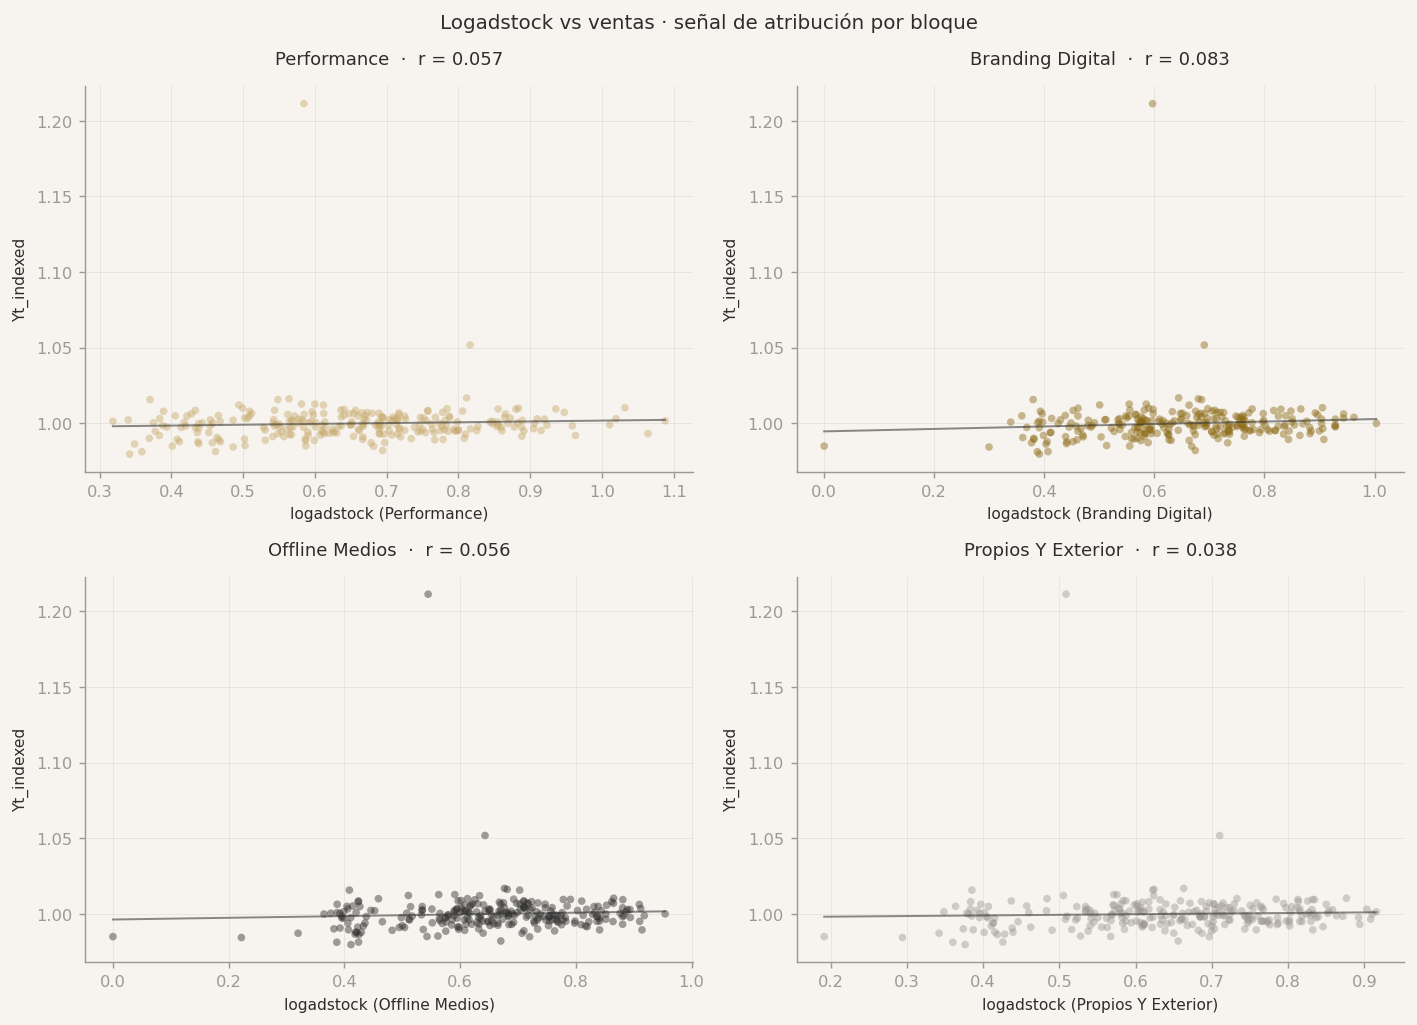

Correlación logadstock → Yt_indexed:
  logadstock_performance                   r = 0.057
  logadstock_branding_digital              r = 0.083
  logadstock_offline_medios                r = 0.056
  logadstock_propios_y_exterior            r = 0.038


In [7]:
# ── Gráfica 2: scatter logadstock vs Yt_indexed, uno por bloque ──────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(LOGADSTOCK_COLS, KM_CHANNELS)):
    ax    = axes[i]
    label = col.replace("logadstock_", "").replace("_", " ").title()
    r     = df[col].corr(df[TARGET_IDX])

    ax.scatter(df[col], df[TARGET_IDX],
               alpha=0.45, s=18, color=color, edgecolors="none")

    m, b = np.polyfit(df[col], df[TARGET_IDX], 1)
    x_rng = np.linspace(df[col].min(), df[col].max(), 60)
    ax.plot(x_rng, m * x_rng + b, color=KM_CHARCOAL, linewidth=1.1, alpha=0.55)

    ax.set_xlabel(f"logadstock ({label})", fontsize=8.5)
    ax.set_ylabel("Yt_indexed", fontsize=8.5)
    ax.set_title(f"{label}  ·  r = {r:.3f}", fontsize=10)

fig.suptitle("Logadstock vs ventas · señal de atribución por bloque",
             fontsize=11, color=KM_CHARCOAL)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "dp_g2_scatter_senal.png"), dpi=150)
plt.show()

print("Correlación logadstock → Yt_indexed:")
for col in LOGADSTOCK_COLS:
    r = df[col].corr(df[TARGET_IDX])
    print(f"  {col:<40s} r = {r:.3f}")

### Gráfica 3 · Multicolinealidad entre bloques

Matriz de correlación de los 4 logadstock. Si ρ entre bloques es bajo (< 0.5),
ElasticNet puede separar la contribución de cada canal; valores altos (> 0.8)
provocan que algún β colapse a cero.

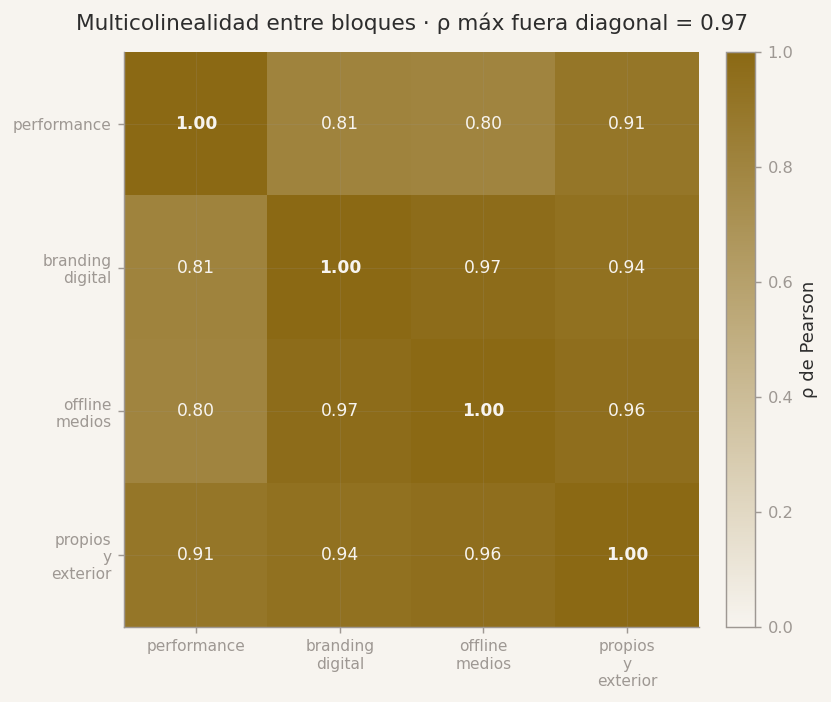

Correlaciones fuera de la diagonal:
  performance               ↔ branding_digital          ρ = 0.809
  performance               ↔ offline_medios            ρ = 0.801
  performance               ↔ propios_y_exterior        ρ = 0.906
  branding_digital          ↔ offline_medios            ρ = 0.972
  branding_digital          ↔ propios_y_exterior        ρ = 0.941
  offline_medios            ↔ propios_y_exterior        ρ = 0.957


In [8]:
# ── Gráfica 3: heatmap de correlación entre logadstock ───────────────────────
corr   = df[LOGADSTOCK_COLS].corr()
short  = [c.replace("logadstock_", "").replace("_", "\n") for c in LOGADSTOCK_COLS]
n      = len(LOGADSTOCK_COLS)

fig, ax = plt.subplots(figsize=(6.5, 5.5))

cmap_km = LinearSegmentedColormap.from_list("km_corr", [KM_CREAM, KM_GOLD_DARK])
im = ax.imshow(corr.values, cmap=cmap_km, vmin=0, vmax=1,
               aspect="equal", interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ρ de Pearson")

ax.set_xticks(range(n));  ax.set_xticklabels(short, fontsize=8.5)
ax.set_yticks(range(n));  ax.set_yticklabels(short, fontsize=8.5)

for i in range(n):
    for j in range(n):
        val = corr.values[i, j]
        txt_color = KM_CREAM if val > 0.6 else KM_CHARCOAL
        weight = "bold" if i == j else "normal"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9.5, color=txt_color, fontweight=weight)

off_diag = corr.values.copy(); np.fill_diagonal(off_diag, 0)
ax.set_title(f"Multicolinealidad entre bloques · ρ máx fuera diagonal = {off_diag.max():.2f}")

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "dp_g3_multicolinealidad.png"), dpi=150)
plt.show()

print("Correlaciones fuera de la diagonal:")
for i in range(n):
    for j in range(i+1, n):
        lab_i = LOGADSTOCK_COLS[i].replace("logadstock_","")
        lab_j = LOGADSTOCK_COLS[j].replace("logadstock_","")
        print(f"  {lab_i:<25s} ↔ {lab_j:<25s} ρ = {corr.values[i,j]:.3f}")

## 6. Feature set + escalado

**19 features totales** — sin year FE ni trend (eliminados por detrending en ETL).

| Tipo | Variables | Nº |
|------|-----------|-----|
| Marketing | logadstock_digital, logadstock_tradicional | 2 |
| Estacionalidad | fourier_sin1/cos1, fourier_sin2/cos2 | 4 |
| Calendario | flags binarios + festivo_local_intensidad | 8 |
| Clima | temperatura, lluvia, turismo | 3 |
| **Total** | | **17** |

In [9]:
YEAR_FE_COLS = [c for c in df.columns if c.startswith("year_")]

FEATURE_COLS  = LOGADSTOCK_COLS + YEAR_FE_COLS + FOURIER_COLS + CONTROLES_CALENDARIO + CONTROLES_CONTINUOS
COLS_TO_SCALE = LOGADSTOCK_COLS + FOURIER_COLS + CONTROLES_CONTINUOS


scaler = StandardScaler()
df[COLS_TO_SCALE] = scaler.fit_transform(df[COLS_TO_SCALE])

print(f"Features: {len(FEATURE_COLS)}")
print(f"  {len(LOGADSTOCK_COLS)} logadstock (bloques)")
print(f"  {len(FOURIER_COLS)} fourier")
print(f"  {len(CONTROLES_CALENDARIO)} calendario")
print(f"  {len(CONTROLES_CONTINUOS)} continuos")
print(f"\nEscalados: {len(COLS_TO_SCALE)} columnas")
print(f"No escalados (flags binarios): {len(CONTROLES_CALENDARIO)}")

Features: 19
  4 logadstock (bloques)
  4 fourier
  8 calendario
  3 continuos

Escalados: 11 columnas
No escalados (flags binarios): 8


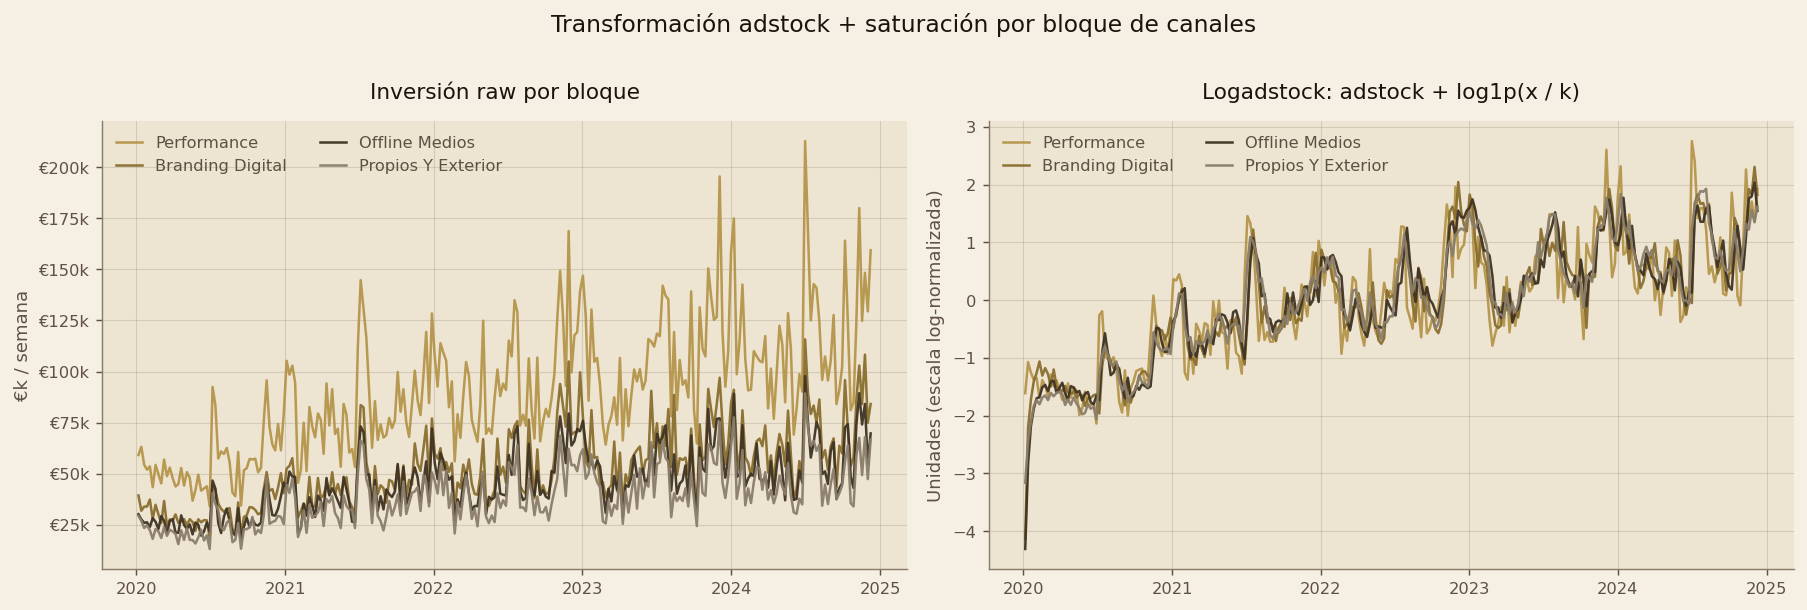

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Paleta del deck (fondo crema + dorados oscuros) ─────────────────────────
BG        = "#F5EFE4"
PANEL     = "#EDE4D2"   # ligeramente más cálido para los ejes
INK       = "#1A140C"
INK_DIM   = "#5E5142"
INK_MUTE  = "#8A7E6B"

# Un color por bloque (orden = INV_GROUP_COLS)
KM_CHANNELS = [
    "#B5954A",   # Performance         – oro medio
    "#8A6E2F",   # Branding Digital    – oro oscuro
    "#3F3324",   # Offline Medios      – café profundo
    "#8A7E6B",   # Propios y Exterior  – topo / crudo
]

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.edgecolor":   INK_MUTE,
    "axes.labelcolor":  INK_DIM,
    "xtick.color":      INK_DIM,
    "ytick.color":      INK_DIM,
    "axes.titlecolor":  INK,
    "text.color":       INK,
    "axes.titlesize":   12,
    "axes.titleweight": "medium",
})

fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(14, 4.6))
fig.patch.set_facecolor(BG)

block_labels = [c.replace("inv_", "").replace("_", " ").title() for c in INV_GROUP_COLS]
log_labels   = [c.replace("logadstock_", "").replace("_", " ").title() for c in LOGADSTOCK_COLS]

for ax in (ax_raw, ax_log):
    ax.set_facecolor(PANEL)
    ax.grid(True, color=INK_MUTE, alpha=0.25, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color(INK_MUTE)

# ── Izquierda: inversión raw ────────────────────────────────────────────────
for col, color, label in zip(INV_GROUP_COLS, KM_CHANNELS, block_labels):
    ax_raw.plot(df[DATE_COL], df[col], lw=1.4, color=color, label=label, alpha=0.95)
ax_raw.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e3:.0f}k"))
ax_raw.xaxis.set_major_locator(mdates.YearLocator())
ax_raw.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_raw.set_title("Inversión raw por bloque", pad=12)
ax_raw.set_ylabel("€k / semana")
ax_raw.legend(
    fontsize=9, ncol=2, frameon=False,
    labelcolor=INK_DIM, handlelength=1.6, loc="upper left",
)

# ── Derecha: logadstock ─────────────────────────────────────────────────────
for col, color, label in zip(LOGADSTOCK_COLS, KM_CHANNELS, log_labels):
    ax_log.plot(df[DATE_COL], df[col], lw=1.4, color=color, label=label, alpha=0.95)
ax_log.xaxis.set_major_locator(mdates.YearLocator())
ax_log.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_log.set_title("Logadstock: adstock + log1p(x / k)", pad=12)
ax_log.set_ylabel("Unidades (escala log-normalizada)")
ax_log.legend(
    fontsize=9, ncol=2, frameon=False,
    labelcolor=INK_DIM, handlelength=1.6, loc="upper left",
)

fig.suptitle(
    "Transformación adstock + saturación por bloque de canales",
    fontsize=13, color=INK, y=1.01,
)
plt.tight_layout()
plt.savefig(
    os.path.join(WAREHOUSE, "dp_g1_raw_vs_logadstock.png"),
    dpi=200, bbox_inches="tight", facecolor=BG,
)
plt.show()

## 7. Guardar

In [11]:
OUT_COLS = (
    [DATE_COL, TARGET_COL, TARGET_IDX, "level_year"]
    + INV_COLS
    + INV_GROUP_COLS
    + FEATURE_COLS
    + ["Yt_scaled"]
)
df[OUT_COLS].to_csv(os.path.join(WAREHOUSE, "data_preparation.csv"), index=False)

annual_levels = df.groupby(df[DATE_COL].dt.year)[TARGET_COL].mean().to_dict()

with open(os.path.join(WAREHOUSE, "scalers.pkl"), "wb") as f:
    pickle.dump({"scaler": scaler, "cols_scaled": COLS_TO_SCALE}, f)

with open(os.path.join(WAREHOUSE, "adstock_params.pkl"), "wb") as f:
    pickle.dump({
        "best_params":      best_params,
        "channel_groups":   CHANNEL_GROUPS,
        "logadstock_cols":  LOGADSTOCK_COLS,
        "feature_cols":     FEATURE_COLS,
        "cols_to_scale":    COLS_TO_SCALE,
        "annual_levels":    annual_levels,
        "saturation_k":     saturation_k,
        "inv_group_cols":   INV_GROUP_COLS,
    }, f)

print(f"✓ data_preparation.csv: {len(OUT_COLS)} cols × {len(df)} filas")
print(f"✓ scalers.pkl")
print(f"✓ adstock_params.pkl")
print(f"\nannual_levels: { {k: f'€{v:,.0f}' for k, v in annual_levels.items()} }")

✓ data_preparation.csv: 36 cols × 258 filas
✓ scalers.pkl
✓ adstock_params.pkl

annual_levels: {2020: '€1,771,338', 2021: '€2,653,224', 2022: '€3,093,563', 2023: '€3,388,641', 2024: '€3,819,229'}
